<a href="https://colab.research.google.com/github/Yashaswini944/credit-card-fraud-detection/blob/main/Credit_Card_Fraud_Dectection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE


In [32]:
#Load the Dataset
df = pd.read_csv("creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
#quick check
df.info()
df['Class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114962 entries, 0 to 114961
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    114962 non-null  int64  
 1   V1      114962 non-null  float64
 2   V2      114962 non-null  float64
 3   V3      114962 non-null  float64
 4   V4      114962 non-null  float64
 5   V5      114962 non-null  float64
 6   V6      114962 non-null  float64
 7   V7      114962 non-null  float64
 8   V8      114962 non-null  float64
 9   V9      114962 non-null  float64
 10  V10     114962 non-null  float64
 11  V11     114962 non-null  float64
 12  V12     114961 non-null  float64
 13  V13     114961 non-null  float64
 14  V14     114961 non-null  float64
 15  V15     114961 non-null  float64
 16  V16     114961 non-null  float64
 17  V17     114961 non-null  float64
 18  V18     114961 non-null  float64
 19  V19     114961 non-null  float64
 20  V20     114961 non-null  float64
 21  V21     11

,count
Class,
0.0,114719
1.0,242


In [31]:
#Exploratory Data Analysis(EDA)
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000,...,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000,114961.000000
mean,46081.563000,-0.254321,-0.014474,0.680774,0.155594,-0.283243,0.093033,-0.115138,0.059047,-0.069232,...,-0.033882,-0.110877,-0.036393,0.011090,0.132304,0.026724,0.001019,0.002058,94.910872,0.002105
std,18497.393069,1.840515,1.635461,1.299916,1.337303,1.336313,1.295510,1.195876,1.228307,1.100385,...,0.736144,0.638775,0.615475,0.595142,0.438953,0.490939,0.390720,0.317051,257.019966,0.045833
min,0.000000,-56.407510,-72.715728,-33.680984,-5.172595,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.534330,-9.390980,-9.617915,0.000000,0.000000
25%,35135.000000,-1.021273,-0.588759,0.175483,-0.706597,-0.904604,-0.650560,-0.603523,-0.133980,-0.702131,...,-0.225051,-0.539090,-0.175476,-0.324119,-0.131773,-0.323044,-0.060932,-0.004723,6.950000,0.000000
50%,47926.000000,-0.262410,0.085674,0.755425,0.183506,-0.316182,-0.160508,-0.067890,0.077769,-0.134441,...,-0.057871,-0.088085,-0.048507,0.067072,0.169540,-0.065767,0.010666,0.023424,25.000000,0.000000
75%,61141.000000,1.155543,0.750082,1.377496,1.016316,0.243646,0.484417,0.411126,0.369321,0.517456,...,0.118275,0.309164,0.081435,0.408176,0.420138,0.293114,0.084748,0.077098,85.440000,0.000000
max,73690.000000,1.960497,18.902453,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,27.202839,10.503090,19.002942,4.016342,5.541598,3.517346,12.152401,33.847808,19656.530000,1.000000


In [11]:
#check missing values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


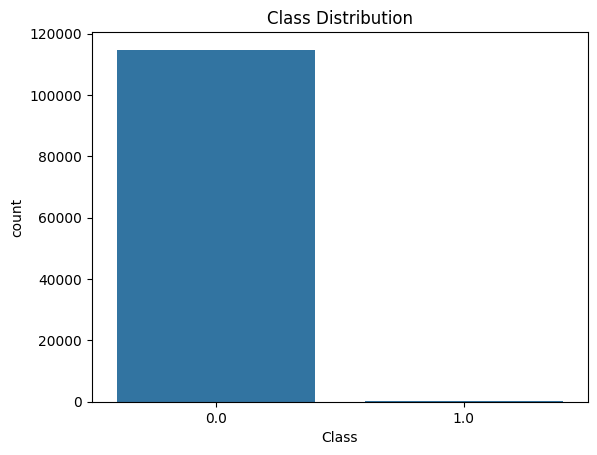

In [12]:
#plot class imbalance
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

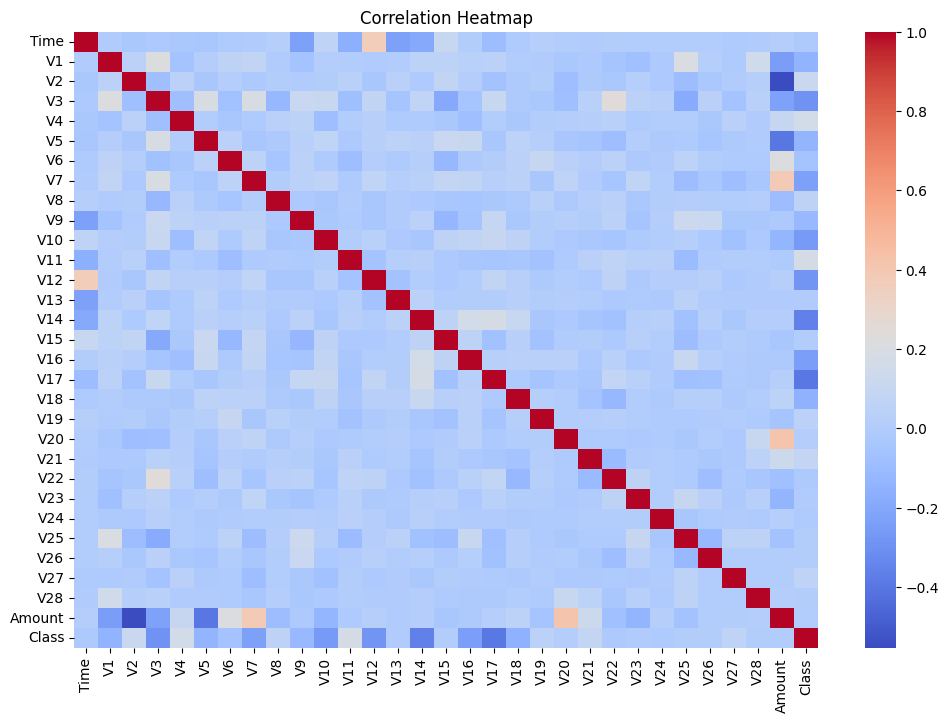

In [13]:
#correlation heatmap(optional)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
df = df.dropna(subset=['Class'])
df['Class'] = df['Class'].astype(int)   # convert float → int (0/1)

In [16]:
df['Class'].isnull().sum()

np.int64(0)

In [17]:
#train-test split
# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split to maintain fraud ratio
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Fraud ratio in training set:")
print(y_train.value_counts(normalize=True))
print("Fraud ratio in test set:")
print(y_test.value_counts(normalize=True))



Training set shape: (91968, 30)
Test set shape: (22993, 30)
Fraud ratio in training set:
Class
0    0.997891
1    0.002109
Name: proportion, dtype: float64
Fraud ratio in test set:
Class
0    0.997912
1    0.002088
Name: proportion, dtype: float64


What This Step Achieves

Prevents the model from being biased by large values in Amount

Ensures Time doesn’t distort distance‑based models

Keeps PCA features untouched (they’re already scaled)

This prepares your dataset for SMOTE and model training.

In [30]:
#scale the features(Feature Scaling)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Copy to avoid modifying original data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Columns to scale
cols_to_scale = ['Time', 'Amount']

# Fit on training data only
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform test data
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


In [29]:
#Handling Imbalance with SMOTE(apply SMOTE to the traning set)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())


Before SMOTE: Class
0    91774
1      194
Name: count, dtype: int64
After SMOTE: Class
0    91774
1    91774
Name: count, dtype: int64


In [28]:
#Train Model 1 : Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)

log_reg.fit(X_train_res, y_train_res)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))


Logistic Regression Accuracy: 0.9776018788326882
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     22945
           1       0.08      0.94      0.15        48

    accuracy                           0.98     22993
   macro avg       0.54      0.96      0.57     22993
weighted avg       1.00      0.98      0.99     22993

ROC-AUC: 0.9859818769521318


In [27]:
#Train Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


Random Forest Accuracy: 0.9994781020310529
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22945
           1       0.93      0.81      0.87        48

    accuracy                           1.00     22993
   macro avg       0.96      0.91      0.93     22993
weighted avg       1.00      1.00      1.00     22993

ROC-AUC: 0.9823459177743881


In [26]:
#Train Model 3: XGBoost

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))


XGBoost Accuracy: 0.9993041360414039
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22945
           1       0.81      0.88      0.84        48

    accuracy                           1.00     22993
   macro avg       0.90      0.94      0.92     22993
weighted avg       1.00      1.00      1.00     22993

ROC-AUC: 0.9868408149923731


In [23]:
#Model Comparison Table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ]
})

results

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.977602,0.985982
1,Random Forest,0.999478,0.982346
2,XGBoost,0.999304,0.986841


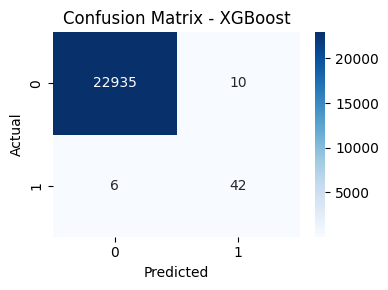

In [33]:
#Confusion Matrix for XGBoost
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

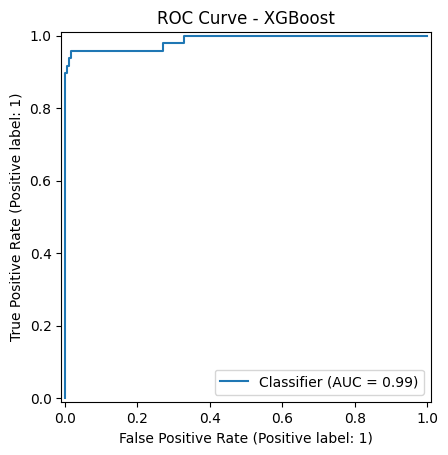

In [25]:
#ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba_xgb)
plt.title("ROC Curve - XGBoost")
plt.show()